In [1]:
from platform import python_version

print(python_version())

3.10.12


In [2]:
import os
import time
import glob
#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, Dataset
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import autocast
from tqdm import tqdm
import random

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler

import pandas as pd
import AnoDDPM.simplex as simplex

from monai.metrics import compute_iou

#print_config()

/home/fehrdelt/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
DEVICE_TYPE = "cuda:0"

In [4]:
ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

set_determinism(0)

IMAGE_SIZE = 128

In [5]:

class Get2DSlice(transforms.Transform):
    """
    Fetch the middle slice of a 3D volume.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.offset = offset

    def __call__(self, data):
        #print(data.shape)
        if self.axis==0:
            return data[:, data.shape[1]//2+self.offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.offset]

class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data


In [6]:


def generate_simplex_noise(simplexObj, shape):
    """Generate spatially correlated simplex noise."""

    simplexObj.newSeed()

    if len(shape) ==2:
        # take a slice t from the 3-dimensional noise function as we found that artefacts 
        # were introduced when sampling from the 2-dimensional noise function
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[0], shape[1]), octaves=6, persistence=0.8, frequency=64)[12,...]
    elif len(shape) == 3:
        simplex = simplexObj.rand_3d_octaves(shape=shape, octaves=6, persistence=0.8, frequency=64)
    elif len(shape) == 4 and shape[1] == 1: # to make it work with shapes of type (batch_size, 1, height, width)
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[2], shape[3]), octaves=6, persistence=0.8, frequency=64)
        simplex = np.expand_dims(simplex, axis=1)

    return torch.tensor(simplex, dtype=torch.float32)

from monai.utils import StrEnum
from typing import Union

class DDPMPredictionType(StrEnum):
    """
    Set of valid prediction type names for the DDPM scheduler's `prediction_type` argument.

    epsilon: predicting the noise of the diffusion process
    sample: directly predicting the noisy sample
    v_prediction: velocity prediction, see section 2.4 https://imagen.research.google/video/paper.pdf
    """

    EPSILON = "epsilon"
    SAMPLE = "sample"
    V_PREDICTION = "v_prediction"

class SimplexDDPMScheduler(DDPMScheduler):
    def __init__(self, *args, noise_scale=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.noise_scale = noise_scale
        self.simplex_obj = simplex.Simplex_CLASS()
        self.simplex_obj.newSeed()

    #def step(
    #    self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: torch.Generator | None = None
    #) -> tuple[torch.Tensor, torch.Tensor]:
    def step(
        self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: Union[torch.Generator, None] = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Predict the sample at the previous timestep by reversing the SDE. Core function to propagate the diffusion
        process from the learned model outputs (most often the predicted noise).

        Args:
            model_output: direct output from learned diffusion model.
            timestep: current discrete timestep in the diffusion chain.
            sample: current instance of sample being created by diffusion process.
            generator: random number generator.

        Returns:
            pred_prev_sample: Predicted previous sample
        """
        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.prediction_type == DDPMPredictionType.EPSILON:
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.prediction_type == DDPMPredictionType.SAMPLE:
            pred_original_sample = model_output
        elif self.prediction_type == DDPMPredictionType.V_PREDICTION:
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output

        # 3. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = torch.clamp(
                pred_original_sample, self.clip_sample_values[0], self.clip_sample_values[1]
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * self.betas[timestep]) / beta_prod_t
        current_sample_coeff = self.alphas[timestep] ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance: torch.Tensor = torch.tensor(0)
        if timestep > 0:
            self.simplex_obj.newSeed()
            noise = generate_simplex_noise(self.simplex_obj, shape=model_output.size()).to(model_output.device)
            
            """ #TODO
            noise = torch.randn(
                model_output.size(),
                dtype=model_output.dtype,
                layout=model_output.layout,
                generator=generator,
                device=model_output.device,
            )"""
            variance = (self._get_variance(timestep, predicted_variance=predicted_variance) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample, pred_original_sample


In [7]:

device = torch.device(DEVICE_TYPE)
simplexObj = simplex.Simplex_CLASS()


model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=(0, 128, 128, 256),
)
model.to(device)


num_train_timesteps = 1000
scheduler = SimplexDDPMScheduler(num_train_timesteps=num_train_timesteps)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)

In [8]:

model.load_state_dict(torch.load(os.path.join(ROOT_DIR+"AnoDiffExperiments/best_models/experiment_3", "exp_3_6_best_model.pth"), map_location=DEVICE_TYPE))
model.eval()


DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler

In [9]:

@torch.no_grad()
def my_sample(image, timesteps=100, progress_bar=True, return_first_noisy_image=False):
    
    
    num_infer_timesteps = timesteps #100 # higher number = more noise at first timestep, more denoising steps
    
    infer_scheduler = SimplexDDPMScheduler(num_train_timesteps=num_infer_timesteps)

    all_next_timesteps = torch.cat((scheduler.timesteps[1:], torch.tensor([0], dtype=infer_scheduler.timesteps.dtype)))

    first_noisy_image = torch.zeros_like(image)

    if progress_bar:
        progress_bar = tqdm(
            zip(infer_scheduler.timesteps, all_next_timesteps),
            total=min(len(infer_scheduler.timesteps), len(all_next_timesteps)),
        )
    else:
        progress_bar = zip(infer_scheduler.timesteps, all_next_timesteps)
            
            
    for t, next_t in progress_bar:          # va de num_infer_timesteps à 0
        # 1. predict noise model_output
        diffusion_model = model
        
        model_output = diffusion_model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
        # 2. compute previous image: x_t -> x_t-1
        
        image, _ = infer_scheduler.step(model_output, t, image)

        if t == num_infer_timesteps-1:
            first_noisy_image = image

    if return_first_noisy_image:
        return image, first_noisy_image
    else:
        return image

## Healthy Reconstruction

In [10]:

test_reconstruction_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/final_adc_dataset_small_with_augmentation_by_registration/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        test_reconstruction_images_path.append(ROOT_DIR+line[0])

205it [00:00, 83422.17it/s]


In [11]:
#val_datalist = sorted(val_images_path)
test_reconstruction_datalist = test_reconstruction_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 32
num_workers = 4

In [12]:
test_reconstruction_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        SetBackgroundToZero()
    ]
)
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_reconstruction_transforms)
test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205/205 [00:47<00:00,  4.35it/s]


The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


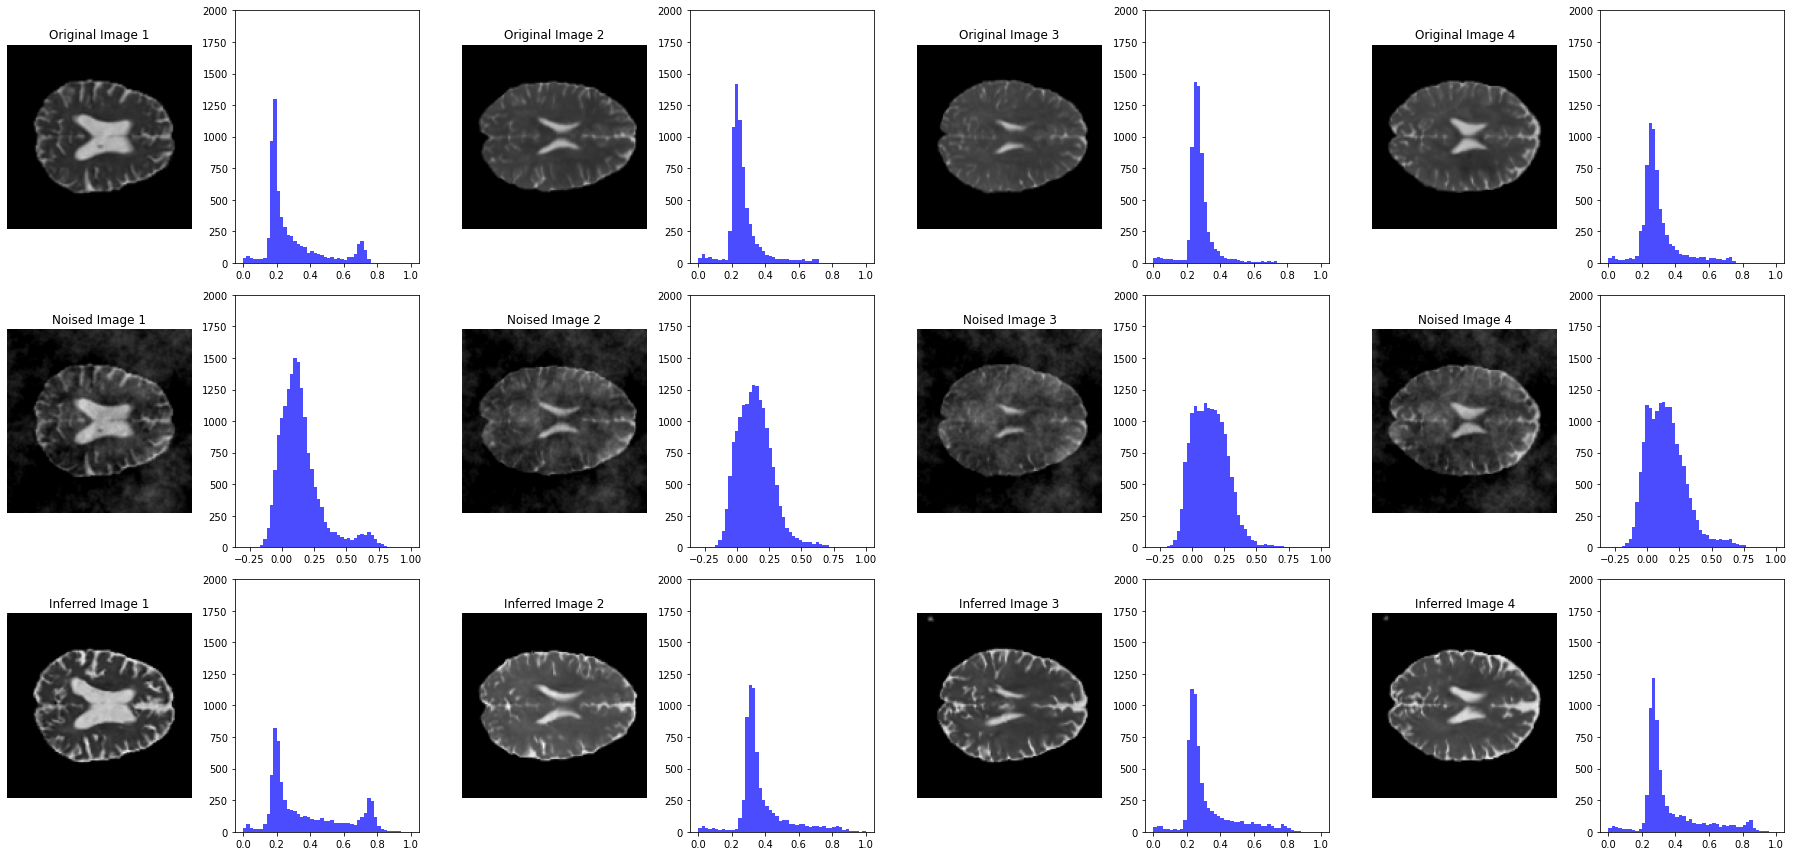

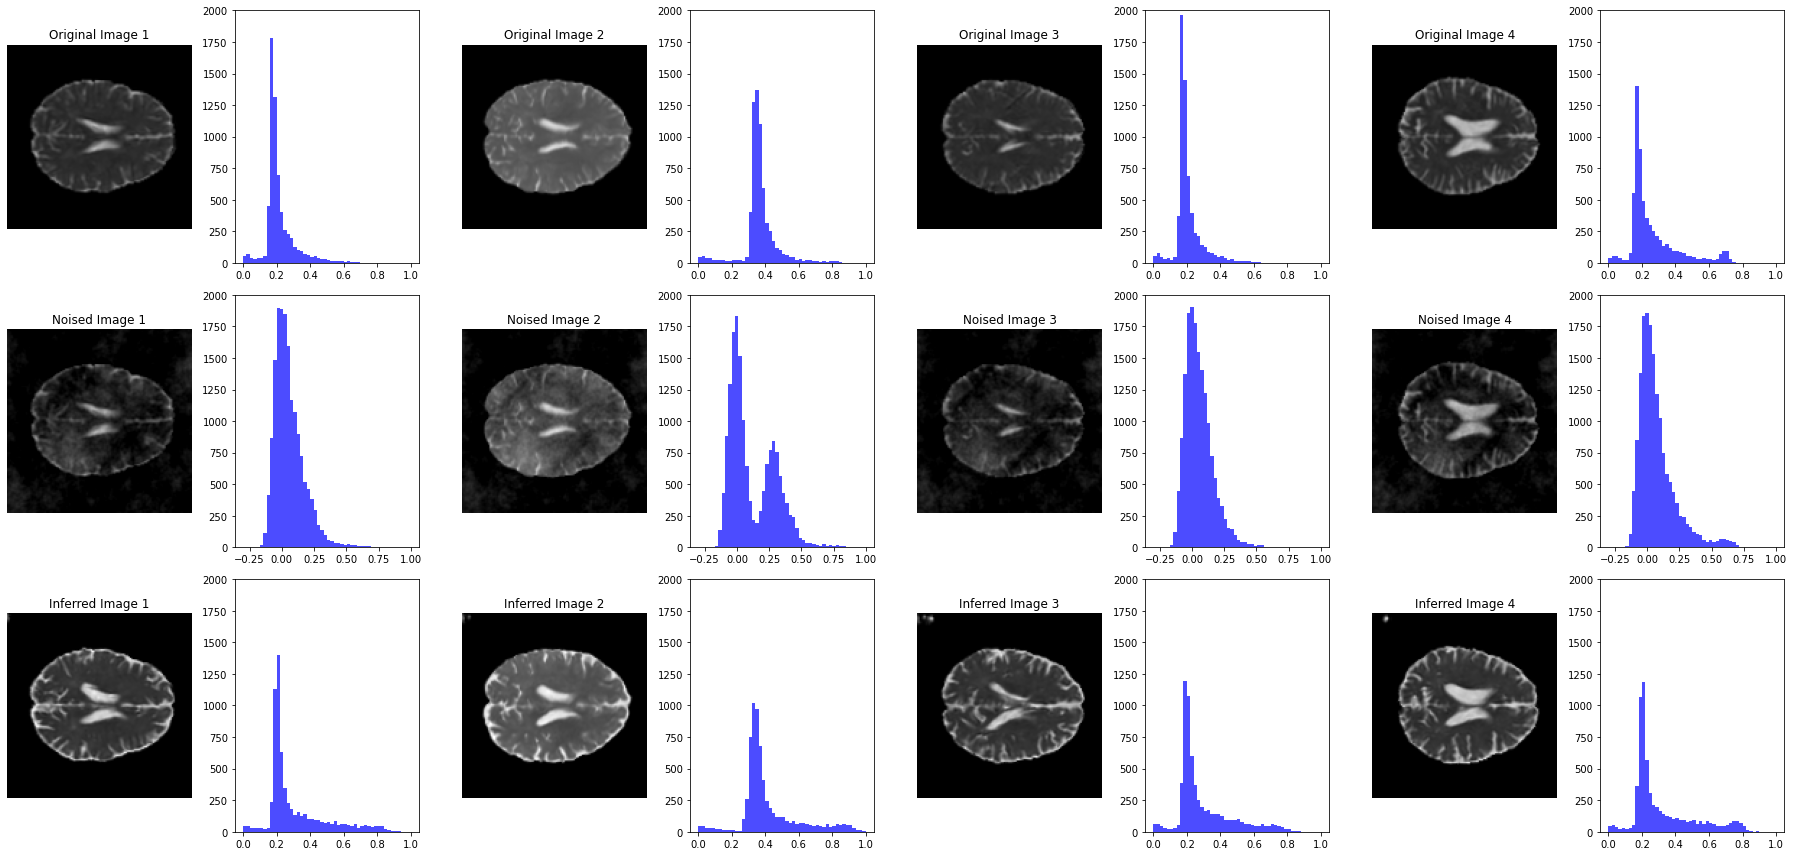

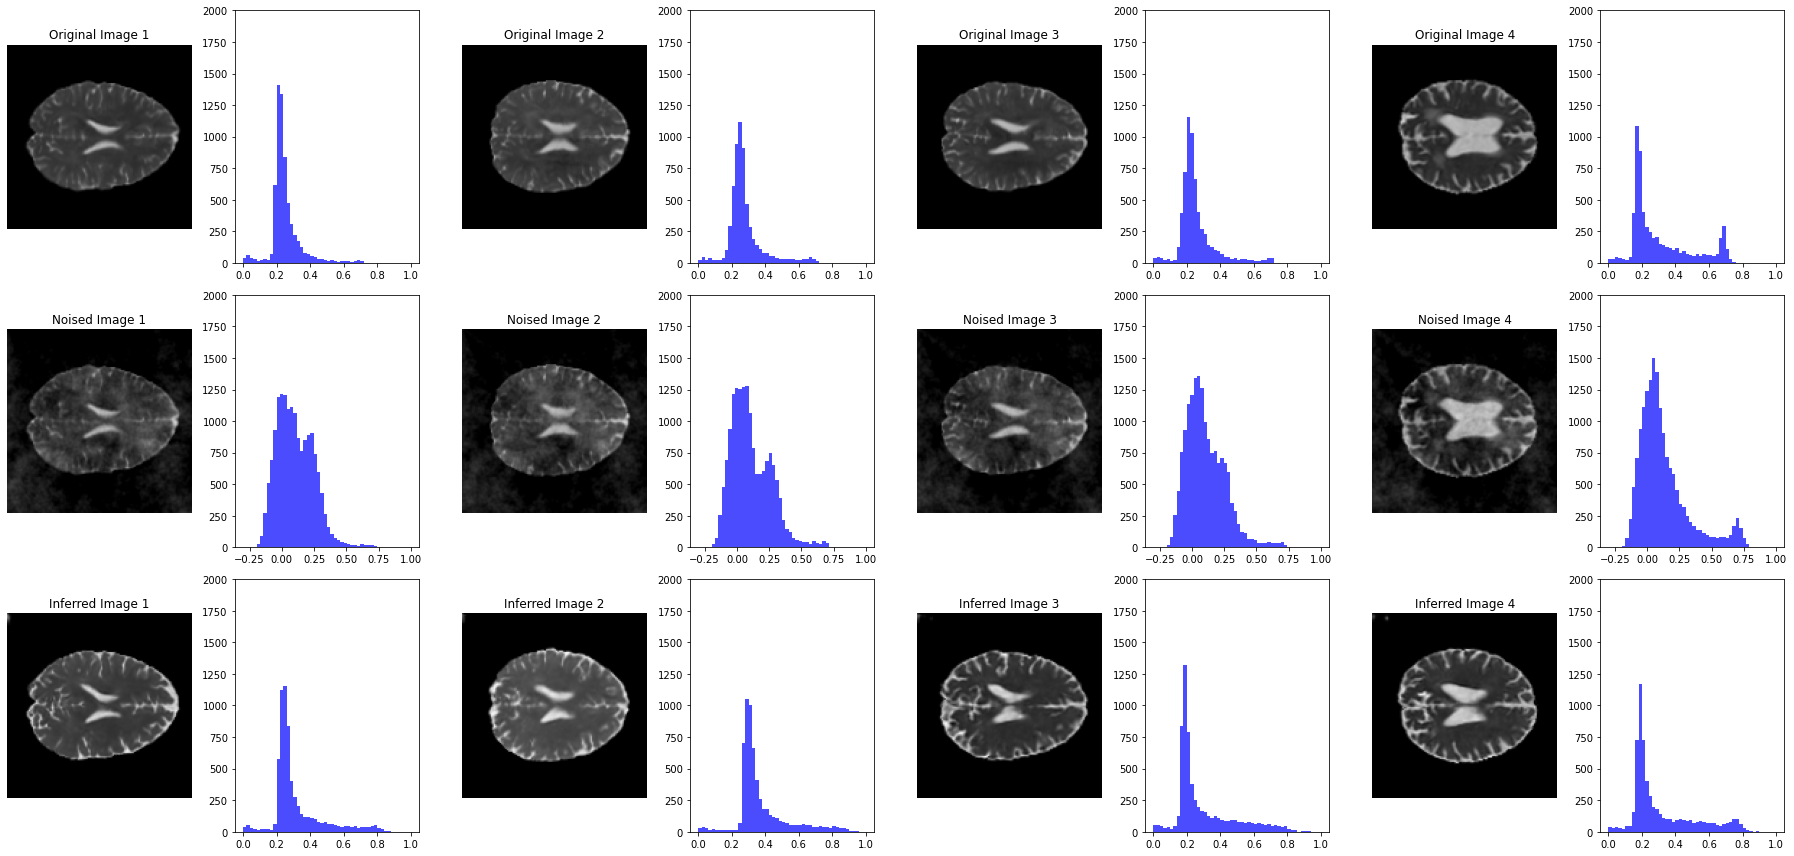

In [ ]:
infer_timesteps = 400

for i,(image_batch) in enumerate(test_reconstruction_loader):
    if i>2:break

    test_images = image_batch.to(device)

    with autocast(device_type=DEVICE_TYPE, enabled=True):
        # Perform 5 inferences and average the results
        infered_images = []

        infered, first_noisy_images = my_sample(test_images, timesteps=infer_timesteps, progress_bar=False, return_first_noisy_image=True)
    
    
    fig, axes = plt.subplots(3, 8, figsize=(25, 12))

    for idx in range(min(4, test_images.shape[0])):

        # Original test images
        original_image = test_images[idx, 0].cpu().numpy()
        axes[0, idx*2].imshow(original_image, cmap='gray', vmin=0, vmax=1)
        axes[0, idx*2].set_title(f'Original Image {idx+1}')
        axes[0, idx*2].axis('off')

        axes[0, idx*2+1].hist(original_image[original_image>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
        axes[0, idx*2+1].set_ylim(0, 2000)
        
        # First noisy images
        noisy_image = first_noisy_images[idx, 0].cpu().numpy()
        axes[1, idx*2].imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
        axes[1, idx*2].set_title(f'Noised Image {idx+1}')
        axes[1, idx*2].axis('off')

        axes[1, idx*2+1].hist(noisy_image.flatten(), bins=50, color='blue', alpha=0.7, range=(-0.3, 1.0))
        axes[1, idx*2+1].set_ylim(0, 2000)

        # Inferred images
        infered_image = infered[idx, 0].cpu().numpy()
        axes[2, idx*2].imshow(infered_image, cmap='gray', vmin=0, vmax=1)
        axes[2, idx*2].set_title(f'Inferred Image {idx+1}')
        axes[2, idx*2].axis('off')

        axes[2, idx*2+1].hist(infered_image[infered_image>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
        axes[2, idx*2+1].set_ylim(0, 2000)

    plt.tight_layout()
    plt.show()


## Anomaly Detection

In [10]:

large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in large_group]
large_group_masks = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_masks_registered/"+filename for filename in large_group]

medium_group = ['sub-strokecase0001_ses-0001_msk.nii.gz', 'sub-strokecase0003_ses-0001_msk.nii.gz', 'sub-strokecase0011_ses-0001_msk.nii.gz', 'sub-strokecase0013_ses-0001_msk.nii.gz', 'sub-strokecase0015_ses-0001_msk.nii.gz', 'sub-strokecase0021_ses-0001_msk.nii.gz', 'sub-strokecase0027_ses-0001_msk.nii.gz', 'sub-strokecase0033_ses-0001_msk.nii.gz', 'sub-strokecase0039_ses-0001_msk.nii.gz', 'sub-strokecase0043_ses-0001_msk.nii.gz', 'sub-strokecase0052_ses-0001_msk.nii.gz', 'sub-strokecase0057_ses-0001_msk.nii.gz', 'sub-strokecase0065_ses-0001_msk.nii.gz', 'sub-strokecase0085_ses-0001_msk.nii.gz', 'sub-strokecase0092_ses-0001_msk.nii.gz', 'sub-strokecase0101_ses-0001_msk.nii.gz', 'sub-strokecase0102_ses-0001_msk.nii.gz', 'sub-strokecase0114_ses-0001_msk.nii.gz', 'sub-strokecase0116_ses-0001_msk.nii.gz', 'sub-strokecase0120_ses-0001_msk.nii.gz', 'sub-strokecase0122_ses-0001_msk.nii.gz', 'sub-strokecase0124_ses-0001_msk.nii.gz', 'sub-strokecase0127_ses-0001_msk.nii.gz', 'sub-strokecase0140_ses-0001_msk.nii.gz', 'sub-strokecase0146_ses-0001_msk.nii.gz', 'sub-strokecase0153_ses-0001_msk.nii.gz', 'sub-strokecase0154_ses-0001_msk.nii.gz', 'sub-strokecase0155_ses-0001_msk.nii.gz', 'sub-strokecase0164_ses-0001_msk.nii.gz', 'sub-strokecase0165_ses-0001_msk.nii.gz', 'sub-strokecase0166_ses-0001_msk.nii.gz', 'sub-strokecase0168_ses-0001_msk.nii.gz', 'sub-strokecase0178_ses-0001_msk.nii.gz', 'sub-strokecase0179_ses-0001_msk.nii.gz', 'sub-strokecase0180_ses-0001_msk.nii.gz', 'sub-strokecase0186_ses-0001_msk.nii.gz', 'sub-strokecase0188_ses-0001_msk.nii.gz', 'sub-strokecase0189_ses-0001_msk.nii.gz', 'sub-strokecase0190_ses-0001_msk.nii.gz', 'sub-strokecase0191_ses-0001_msk.nii.gz', 'sub-strokecase0192_ses-0001_msk.nii.gz', 'sub-strokecase0194_ses-0001_msk.nii.gz', 'sub-strokecase0195_ses-0001_msk.nii.gz', 'sub-strokecase0199_ses-0001_msk.nii.gz', 'sub-strokecase0204_ses-0001_msk.nii.gz', 'sub-strokecase0206_ses-0001_msk.nii.gz', 'sub-strokecase0207_ses-0001_msk.nii.gz', 'sub-strokecase0208_ses-0001_msk.nii.gz', 'sub-strokecase0209_ses-0001_msk.nii.gz', 'sub-strokecase0215_ses-0001_msk.nii.gz', 'sub-strokecase0219_ses-0001_msk.nii.gz', 'sub-strokecase0220_ses-0001_msk.nii.gz', 'sub-strokecase0001_ses-0001_msk.nii.gz', 'sub-strokecase0003_ses-0001_msk.nii.gz', 'sub-strokecase0011_ses-0001_msk.nii.gz', 'sub-strokecase0013_ses-0001_msk.nii.gz', 'sub-strokecase0015_ses-0001_msk.nii.gz', 'sub-strokecase0021_ses-0001_msk.nii.gz', 'sub-strokecase0027_ses-0001_msk.nii.gz', 'sub-strokecase0033_ses-0001_msk.nii.gz', 'sub-strokecase0039_ses-0001_msk.nii.gz', 'sub-strokecase0043_ses-0001_msk.nii.gz', 'sub-strokecase0052_ses-0001_msk.nii.gz', 'sub-strokecase0057_ses-0001_msk.nii.gz', 'sub-strokecase0065_ses-0001_msk.nii.gz', 'sub-strokecase0085_ses-0001_msk.nii.gz', 'sub-strokecase0092_ses-0001_msk.nii.gz', 'sub-strokecase0101_ses-0001_msk.nii.gz', 'sub-strokecase0102_ses-0001_msk.nii.gz', 'sub-strokecase0114_ses-0001_msk.nii.gz', 'sub-strokecase0116_ses-0001_msk.nii.gz', 'sub-strokecase0120_ses-0001_msk.nii.gz', 'sub-strokecase0122_ses-0001_msk.nii.gz', 'sub-strokecase0124_ses-0001_msk.nii.gz', 'sub-strokecase0127_ses-0001_msk.nii.gz', 'sub-strokecase0140_ses-0001_msk.nii.gz', 'sub-strokecase0146_ses-0001_msk.nii.gz', 'sub-strokecase0153_ses-0001_msk.nii.gz', 'sub-strokecase0154_ses-0001_msk.nii.gz', 'sub-strokecase0155_ses-0001_msk.nii.gz', 'sub-strokecase0164_ses-0001_msk.nii.gz', 'sub-strokecase0165_ses-0001_msk.nii.gz', 'sub-strokecase0166_ses-0001_msk.nii.gz', 'sub-strokecase0168_ses-0001_msk.nii.gz', 'sub-strokecase0178_ses-0001_msk.nii.gz', 'sub-strokecase0179_ses-0001_msk.nii.gz', 'sub-strokecase0180_ses-0001_msk.nii.gz', 'sub-strokecase0186_ses-0001_msk.nii.gz', 'sub-strokecase0188_ses-0001_msk.nii.gz', 'sub-strokecase0189_ses-0001_msk.nii.gz', 'sub-strokecase0190_ses-0001_msk.nii.gz', 'sub-strokecase0191_ses-0001_msk.nii.gz', 'sub-strokecase0192_ses-0001_msk.nii.gz', 'sub-strokecase0194_ses-0001_msk.nii.gz', 'sub-strokecase0195_ses-0001_msk.nii.gz', 'sub-strokecase0199_ses-0001_msk.nii.gz', 'sub-strokecase0204_ses-0001_msk.nii.gz', 'sub-strokecase0206_ses-0001_msk.nii.gz', 'sub-strokecase0207_ses-0001_msk.nii.gz', 'sub-strokecase0208_ses-0001_msk.nii.gz', 'sub-strokecase0209_ses-0001_msk.nii.gz', 'sub-strokecase0215_ses-0001_msk.nii.gz', 'sub-strokecase0219_ses-0001_msk.nii.gz', 'sub-strokecase0220_ses-0001_msk.nii.gz', 'sub-strokecase0226_ses-0001_msk.nii.gz', 'sub-strokecase0227_ses-0001_msk.nii.gz', 'sub-strokecase0236_ses-0001_msk.nii.gz', 'sub-strokecase0238_ses-0001_msk.nii.gz', 'sub-strokecase0243_ses-0001_msk.nii.gz', 'sub-strokecase0245_ses-0001_msk.nii.gz', 'sub-strokecase0248_ses-0001_msk.nii.gz']
medium_group_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in medium_group]
medium_group_masks = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_masks_registered/"+filename for filename in medium_group]

small_group = ['sub-strokecase0004_ses-0001_msk.nii.gz', 'sub-strokecase0009_ses-0001_msk.nii.gz', 'sub-strokecase0010_ses-0001_msk.nii.gz', 'sub-strokecase0017_ses-0001_msk.nii.gz', 'sub-strokecase0022_ses-0001_msk.nii.gz', 'sub-strokecase0024_ses-0001_msk.nii.gz', 'sub-strokecase0026_ses-0001_msk.nii.gz', 'sub-strokecase0036_ses-0001_msk.nii.gz', 'sub-strokecase0038_ses-0001_msk.nii.gz', 'sub-strokecase0040_ses-0001_msk.nii.gz', 'sub-strokecase0041_ses-0001_msk.nii.gz', 'sub-strokecase0049_ses-0001_msk.nii.gz', 'sub-strokecase0053_ses-0001_msk.nii.gz', 'sub-strokecase0054_ses-0001_msk.nii.gz', 'sub-strokecase0056_ses-0001_msk.nii.gz', 'sub-strokecase0064_ses-0001_msk.nii.gz', 'sub-strokecase0067_ses-0001_msk.nii.gz', 'sub-strokecase0074_ses-0001_msk.nii.gz', 'sub-strokecase0076_ses-0001_msk.nii.gz', 'sub-strokecase0080_ses-0001_msk.nii.gz', 'sub-strokecase0082_ses-0001_msk.nii.gz', 'sub-strokecase0084_ses-0001_msk.nii.gz', 'sub-strokecase0090_ses-0001_msk.nii.gz', 'sub-strokecase0095_ses-0001_msk.nii.gz', 'sub-strokecase0097_ses-0001_msk.nii.gz', 'sub-strokecase0108_ses-0001_msk.nii.gz', 'sub-strokecase0110_ses-0001_msk.nii.gz', 'sub-strokecase0129_ses-0001_msk.nii.gz', 'sub-strokecase0137_ses-0001_msk.nii.gz', 'sub-strokecase0145_ses-0001_msk.nii.gz', 'sub-strokecase0152_ses-0001_msk.nii.gz', 'sub-strokecase0158_ses-0001_msk.nii.gz', 'sub-strokecase0159_ses-0001_msk.nii.gz', 'sub-strokecase0163_ses-0001_msk.nii.gz', 'sub-strokecase0167_ses-0001_msk.nii.gz', 'sub-strokecase0169_ses-0001_msk.nii.gz', 'sub-strokecase0182_ses-0001_msk.nii.gz', 'sub-strokecase0183_ses-0001_msk.nii.gz', 'sub-strokecase0185_ses-0001_msk.nii.gz', 'sub-strokecase0187_ses-0001_msk.nii.gz', 'sub-strokecase0193_ses-0001_msk.nii.gz', 'sub-strokecase0196_ses-0001_msk.nii.gz', 'sub-strokecase0197_ses-0001_msk.nii.gz', 'sub-strokecase0200_ses-0001_msk.nii.gz', 'sub-strokecase0210_ses-0001_msk.nii.gz', 'sub-strokecase0214_ses-0001_msk.nii.gz', 'sub-strokecase0218_ses-0001_msk.nii.gz', 'sub-strokecase0004_ses-0001_msk.nii.gz', 'sub-strokecase0009_ses-0001_msk.nii.gz', 'sub-strokecase0010_ses-0001_msk.nii.gz', 'sub-strokecase0017_ses-0001_msk.nii.gz', 'sub-strokecase0022_ses-0001_msk.nii.gz', 'sub-strokecase0024_ses-0001_msk.nii.gz', 'sub-strokecase0026_ses-0001_msk.nii.gz', 'sub-strokecase0036_ses-0001_msk.nii.gz', 'sub-strokecase0038_ses-0001_msk.nii.gz', 'sub-strokecase0040_ses-0001_msk.nii.gz', 'sub-strokecase0041_ses-0001_msk.nii.gz', 'sub-strokecase0049_ses-0001_msk.nii.gz', 'sub-strokecase0053_ses-0001_msk.nii.gz', 'sub-strokecase0054_ses-0001_msk.nii.gz', 'sub-strokecase0056_ses-0001_msk.nii.gz', 'sub-strokecase0064_ses-0001_msk.nii.gz', 'sub-strokecase0067_ses-0001_msk.nii.gz', 'sub-strokecase0074_ses-0001_msk.nii.gz', 'sub-strokecase0076_ses-0001_msk.nii.gz', 'sub-strokecase0080_ses-0001_msk.nii.gz', 'sub-strokecase0082_ses-0001_msk.nii.gz', 'sub-strokecase0084_ses-0001_msk.nii.gz', 'sub-strokecase0090_ses-0001_msk.nii.gz', 'sub-strokecase0095_ses-0001_msk.nii.gz', 'sub-strokecase0097_ses-0001_msk.nii.gz', 'sub-strokecase0108_ses-0001_msk.nii.gz', 'sub-strokecase0110_ses-0001_msk.nii.gz', 'sub-strokecase0129_ses-0001_msk.nii.gz', 'sub-strokecase0137_ses-0001_msk.nii.gz', 'sub-strokecase0145_ses-0001_msk.nii.gz', 'sub-strokecase0152_ses-0001_msk.nii.gz', 'sub-strokecase0158_ses-0001_msk.nii.gz', 'sub-strokecase0159_ses-0001_msk.nii.gz', 'sub-strokecase0163_ses-0001_msk.nii.gz', 'sub-strokecase0167_ses-0001_msk.nii.gz', 'sub-strokecase0169_ses-0001_msk.nii.gz', 'sub-strokecase0182_ses-0001_msk.nii.gz', 'sub-strokecase0183_ses-0001_msk.nii.gz', 'sub-strokecase0185_ses-0001_msk.nii.gz', 'sub-strokecase0187_ses-0001_msk.nii.gz', 'sub-strokecase0193_ses-0001_msk.nii.gz', 'sub-strokecase0196_ses-0001_msk.nii.gz', 'sub-strokecase0197_ses-0001_msk.nii.gz', 'sub-strokecase0200_ses-0001_msk.nii.gz', 'sub-strokecase0210_ses-0001_msk.nii.gz', 'sub-strokecase0214_ses-0001_msk.nii.gz', 'sub-strokecase0218_ses-0001_msk.nii.gz', 'sub-strokecase0225_ses-0001_msk.nii.gz', 'sub-strokecase0229_ses-0001_msk.nii.gz', 'sub-strokecase0232_ses-0001_msk.nii.gz', 'sub-strokecase0235_ses-0001_msk.nii.gz', 'sub-strokecase0244_ses-0001_msk.nii.gz', 'sub-strokecase0247_ses-0001_msk.nii.gz', 'sub-strokecase0249_ses-0001_msk.nii.gz']
small_group_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in small_group]
small_group_masks = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_masks_registered/"+filename for filename in small_group]


In [11]:

num_workers = 4
ano_batch_size = 10

In [12]:

test_anomaly_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=+2),
        transforms.ScaleIntensity(minv=0.0, maxv=3000.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=3200.0, b_min=0.0, b_max=1.0, clip=True), # change a_max to increase or decrease intensity of the images after transformation
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
        SetBackgroundToZero(tolerance=0),  # Set background to zero
    ]
)
test_anomaly_large_ds = CacheDataset(data=large_group_images, transform=test_anomaly_transforms)
#test_anomaly_medium_ds = CacheDataset(data=medium_group_images, transform=test_anomaly_transforms)
#test_anomaly_small_ds = CacheDataset(data=small_group_images, transform=test_anomaly_transforms)


test_anomaly_large_loader = DataLoader(
    test_anomaly_large_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)
""" 
test_anomaly_medium_loader = DataLoader(
    test_anomaly_medium_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)
test_anomaly_small_loader = DataLoader(
    test_anomaly_small_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
) """

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 14.22it/s]


' \ntest_anomaly_medium_loader = DataLoader(\n    test_anomaly_medium_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True\n)\ntest_anomaly_small_loader = DataLoader(\n    test_anomaly_small_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True\n) '

In [13]:

test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=+2),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    ]
)
test_masks_large_ds = CacheDataset(data=large_group_masks, transform=test_masks_transforms)
#test_masks_medium_ds = CacheDataset(data=medium_group_masks, transform=test_anomaly_transforms)
#test_masks_small_ds = CacheDataset(data=small_group_masks, transform=test_anomaly_transforms)


test_masks_large_loader = DataLoader(
    test_masks_large_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)
""" 
test_masks_medium_loader = DataLoader(
    test_masks_medium_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)
test_masks_small_loader = DataLoader(
    test_masks_small_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
) """


Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 17.08it/s]


' \ntest_masks_medium_loader = DataLoader(\n    test_masks_medium_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True\n)\ntest_masks_small_loader = DataLoader(\n    test_masks_small_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True\n) '

In [14]:
infer_timesteps = 200

for i,(image_batch, mask_batch) in enumerate(tqdm(zip(test_anomaly_large_loader, test_masks_large_loader))): # i=6 batch is nice
    if i>0:break

    test_images = image_batch.to(device)
    test_masks = mask_batch.to(device)
    test_masks[test_masks>0.5] = 1.0
    test_masks[test_masks<=0.5] = 0.0

    with autocast(device_type=DEVICE_TYPE, enabled=True):
        # Perform 5 inferences and average the results
        infered_images = []

        for _ in range(3):
            infered = my_sample(test_images, timesteps=infer_timesteps, progress_bar=False)
            infered_images.append(infered)


        average_infered_image = torch.stack(infered_images, dim=0).mean(dim=0)


0it [00:00, ?it/s]The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
1it [02:08, 128.00s/it]


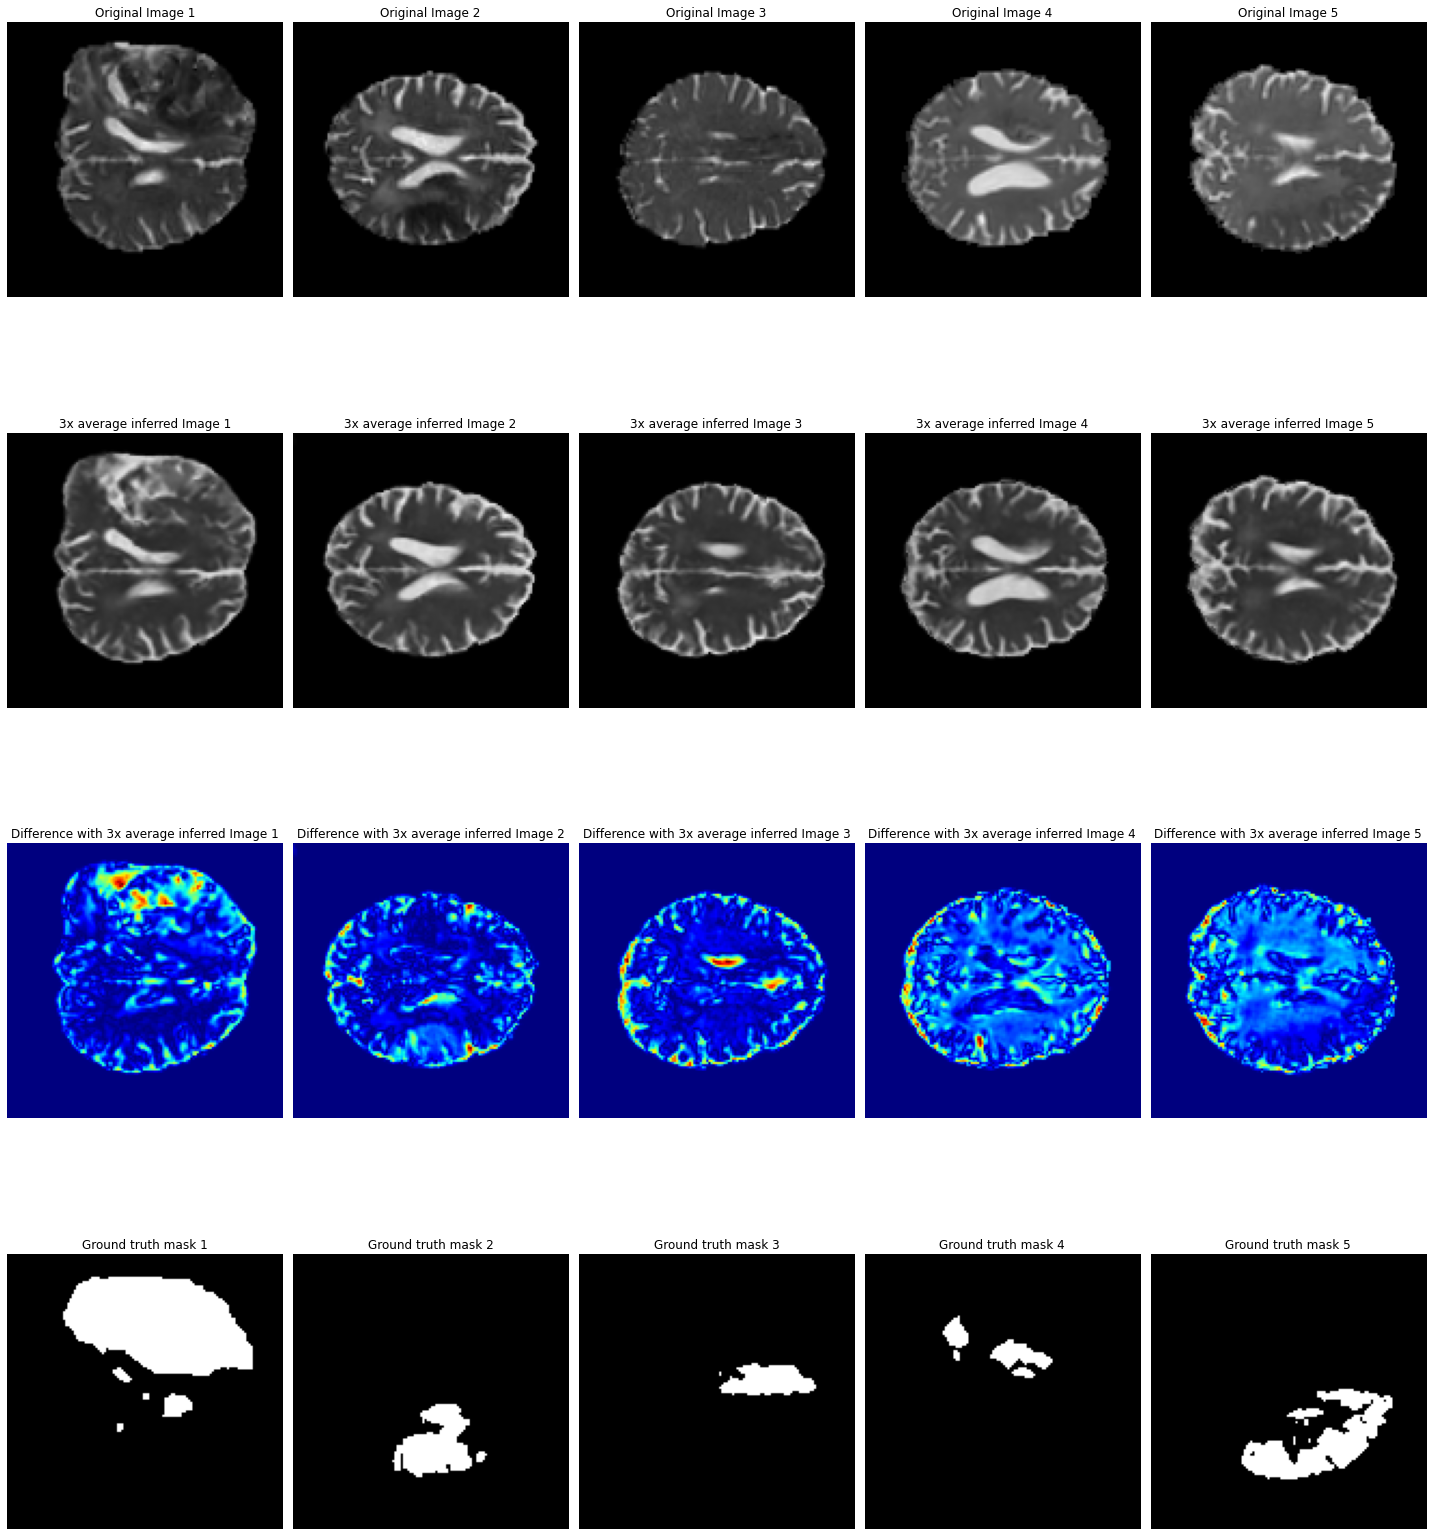

In [18]:
# Create a figure with subplots to display images side by side
fig, axes = plt.subplots(4, 5, figsize=(20, 24))

for idx in range(min(5, test_images.shape[0])):
    # Original test images
    axes[0, idx].imshow(test_images[idx, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0, idx].set_title(f'Original Image {idx+1}')
    axes[0, idx].axis('off')
    
    # Average inferred images
    axes[1, idx].imshow(average_infered_image[idx, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1, idx].set_title(f'3x average inferred Image {idx+1}')
    axes[1, idx].axis('off')

    axes[2, idx].imshow(torch.abs(average_infered_image[idx, 0] - test_images[idx, 0]).cpu().numpy(), cmap='jet')
    axes[2, idx].set_title(f'Difference with 3x average inferred Image {idx+1}')
    axes[2, idx].axis('off')

    axes[3, idx].imshow(test_masks[idx, 0].cpu().numpy(), cmap='gray')
    axes[3, idx].set_title(f'Ground truth mask {idx+1}')
    axes[3, idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def compute(image_loader, mask_loader):


    num_timesteps_to_try = np.arange(10, 500, 10)
    thresholds_to_try = np.arange(0.0, 1.0, 0.01) # from 0.0 to 1.0 with step 0.05

    iou_scores_df = pd.DataFrame(index=num_timesteps_to_try, columns=thresholds_to_try)
    iou_scores_df.fillna(0.0, inplace=True)


    for i,(image_batch, mask_batch) in enumerate(tqdm(zip(image_loader, mask_loader))): # i=6 batch is nice

        test_images = image_batch.to(device)
        test_masks = mask_batch.to(device)
        test_masks[test_masks>0.5] = 1.0
        test_masks[test_masks<=0.5] = 0.0

        for infer_timesteps in num_timesteps_to_try:
            with autocast(device_type=DEVICE_TYPE, enabled=True):
                # Perform 5 inferences and average the results
                infered_images = []
                for _ in range(5):
                    infered_images.append(my_sample(test_images, timesteps=infer_timesteps, progress_bar=False))
                average_infered_image = torch.stack(infered_images, dim=0).mean(dim=0)
        
            for threshold in thresholds_to_try:
                ano_segmentation = torch.abs(average_infered_image - test_images) > threshold
                iou_score = compute_iou(ano_segmentation, test_masks)
                flattened_iou_score = iou_score.cpu().numpy().flatten()
                flattened_iou_score[np.isnan(flattened_iou_score)] = 0.0

                if np.isnan(iou_scores_df.loc[infer_timesteps, threshold]): # if the cell is empty
                    iou_scores_df.loc[infer_timesteps, threshold] = np.sum(flattened_iou_score)
                else:
                    iou_scores_df.loc[infer_timesteps, threshold] += np.sum(flattened_iou_score) # this average is false

    #divide everything by the number of images
    iou_scores_df = iou_scores_df / len(image_loader.dataset)

    return iou_scores_df

In [ ]:

# large group
iou_scores_df_large_group = compute(test_anomaly_large_loader, test_masks_large_loader)

best_iou = iou_scores_df_large_group.max().max()
best_threshold = iou_scores_df_large_group.max(axis=0).idxmax()
best_num_timesteps = iou_scores_df_large_group.max(axis=1).idxmax()

print(f"Best IOU (large group): {best_iou}")
print(f"Best Threshold (large group): {best_threshold}")
print(f"Best Number of Timesteps (large group): {best_num_timesteps}")

iou_scores_df_large_group.to_csv("exp_3_6_scores_iou_large_group.csv")

# medium group
iou_scores_df_medium_group = compute(test_anomaly_medium_loader, test_masks_medium_loader)

best_iou = iou_scores_df_medium_group.max().max()
best_threshold = iou_scores_df_medium_group.max(axis=0).idxmax()
best_num_timesteps = iou_scores_df_medium_group.max(axis=1).idxmax()

print(f"Best IOU (medium group): {best_iou}")
print(f"Best Threshold (medium group): {best_threshold}")
print(f"Best Number of Timesteps (medium group): {best_num_timesteps}")

iou_scores_df_medium_group.to_csv("exp_3_6_scores_iou_medium_group.csv")

# small group
iou_scores_df_small_group = compute(test_anomaly_small_loader, test_masks_small_loader)

best_iou = iou_scores_df_small_group.max().max()
best_threshold = iou_scores_df_small_group.max(axis=0).idxmax()
best_num_timesteps = iou_scores_df_small_group.max(axis=1).idxmax()

print(f"Best IOU (small group): {best_iou}")
print(f"Best Threshold (small group): {best_threshold}")
print(f"Best Number of Timesteps (small group): {best_num_timesteps}")

iou_scores_df_small_group.to_csv("exp_3_6_scores_iou_small_group.csv")